# Assignment TACD 2025/2026


1. Business Understanding
2. Data Understanding
3. Data Transformation
4. Modelling

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split


DATA_DIR = Path("ml-latest-small")
ratings_path = DATA_DIR / "ratings.csv"
movies_path = DATA_DIR / "movies.csv"

## 1. Business Understanding

The business problem is to help a movie platform recommend relevant films to each user based on past interactions. From a business perspective, higher recommendation quality directly translates to increased user engagement, longer session times, and higher retention rates — all of which drive subscription revenue and reduce churn.

Success can be evaluated by the quality of top-N recommendations on unseen data. The primary metrics used are Precision@3 and Recall@3, alongside their harmonic mean F1@3. Precision and Recall are well-suited to this task because they directly reflect the two core objectives of a recommender system: ensuring that every suggested item is relevant to the user, and ensuring that relevant items in the catalog are not missed. NDCG (Normalized Discounted Cumulative Gain) could also be computed as it additionally rewards correct ranking order within the list; however, since the evaluation focuses on whether relevant items appear in the top-k set rather than their precise ordering within it, NDCG was omitted for brevity.

From a practical point of view, the solution should also work well with sparse data and remain usable when users have rated only a small number of movies. A non-personalised popularity baseline, recommending the most-rated movies to every user, will serve as a lower bound to confirm that learned models add value over a trivial solution.

This can be translated into two machine learning problems. The first is an explicit-feedback task, where we predict the rating a user may give to a movie. The second is a ranking task, where we predict which unseen movies should appear at the top of the recommendation list.
From an operational perspective, the main limitations are cold-start users (new users with no history cannot receive personalised recommendations) and the static nature of the dataset (in production, the catalog and user preferences change over time, so models would need periodic retraining).

## 2. Data Understanding

In [2]:
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

ratings["timestamp_dt"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
ratings.head()

ratings shape: (100836, 5)
movies shape: (9742, 3)


,userId,movieId,rating,timestamp,timestamp_dt
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


In [3]:
n_ratings = len(ratings)
n_users = ratings["userId"].nunique()
n_rated_movies = ratings["movieId"].nunique()
catalog_movies = movies["movieId"].nunique()
density = n_ratings / (n_users * n_rated_movies)

print("Number of ratings:", n_ratings)
print("Number of users:", n_users)
print("Number of rated movies:", n_rated_movies)
print("Number of movies in catalog:", catalog_movies)
print("Rating scale:", ratings["rating"].min(), "to", ratings["rating"].max())
print("Average rating:", round(ratings["rating"].mean(), 3))
print("Median rating:", ratings["rating"].median())
print("First interaction:", ratings["timestamp_dt"].min())
print("Last interaction:", ratings["timestamp_dt"].max())
print(f"User-item matrix density: {density:.4%}")

Number of ratings: 100836
Number of users: 610
Number of rated movies: 9724
Number of movies in catalog: 9742
Rating scale: 0.5 to 5.0
Average rating: 3.502
Median rating: 3.5
First interaction: 1996-03-29 18:36:55
Last interaction: 2018-09-24 14:27:30
User-item matrix density: 1.7000%


The dataset contains 610 users and 9724 rated movies. The density is low, so the user-item matrix is sparse.

In [4]:
print("Missing values by column:")
print(ratings.isna().sum())
print("Column types:")
print(ratings.dtypes)
print("Duplicated (userId, movieId) pairs:", ratings.duplicated(subset=["userId", "movieId"]).sum())

Missing values by column:
userId          0
movieId         0
rating          0
timestamp       0
timestamp_dt    0
dtype: int64
Column types:
userId                  int64
movieId                 int64
rating                float64
timestamp               int64
timestamp_dt    datetime64[s]
dtype: object
Duplicated (userId, movieId) pairs: 0


There are no missing values in the `ratings` table and there are no duplicated `(userId, movieId)` pairs.

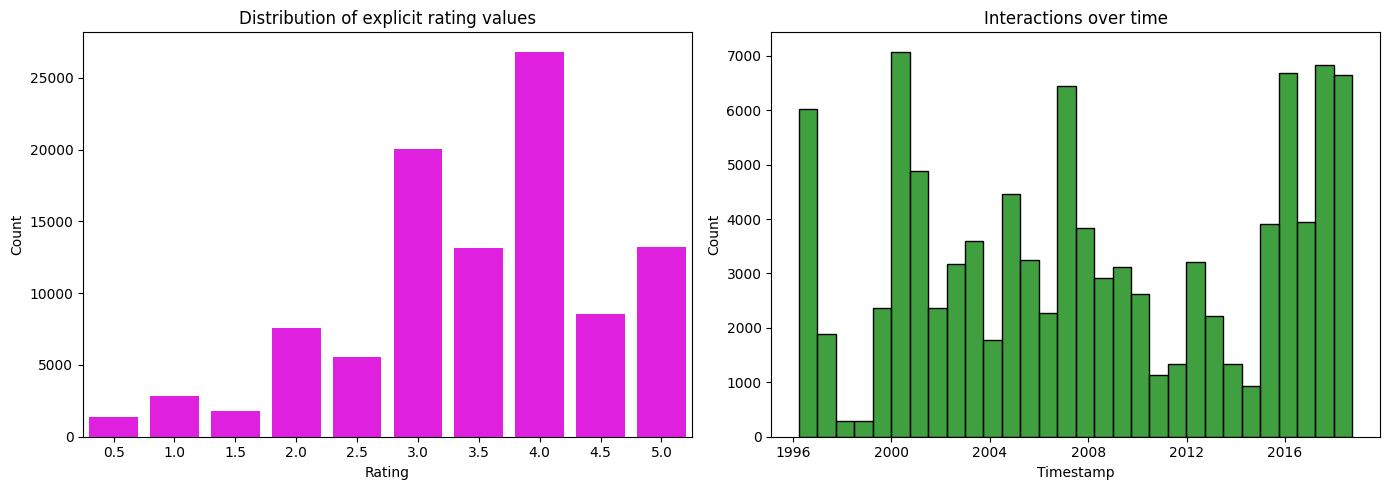

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=ratings, x="rating", ax=axes[0], color="magenta")
axes[0].set_title("Distribution of explicit rating values")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

sns.histplot(ratings["timestamp_dt"], bins=30, ax=axes[1], color="green")
axes[1].set_title("Interactions over time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The rating distribution is concentrated around higher scores, especially 4.0. This indicates that users are more prone to rate movies they like. Interactions over time are irregular, with clear peaks and drops, which shows that activity is not constant across the years.

In [6]:
user_activity = ratings.groupby("userId").size().rename("basket_size")
item_popularity = ratings.groupby("movieId").size().rename("rating_count")

print("Basket size summary:")
print(user_activity.describe())
print("\nMovie popularity summary:")
print(item_popularity.describe())
print("\nTop 10 most active users:")
print(user_activity.sort_values(ascending=False).head(10))
print("\nTop 10 most rated movies:")
top_movies = (item_popularity.sort_values(ascending=False).head(10).reset_index().merge(movies[["movieId", "title"]], on="movieId", how="left"))
print(top_movies[["movieId", "title", "rating_count"]].to_string(index=False))

Basket size summary:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: basket_size, dtype: float64

Movie popularity summary:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating_count, dtype: float64

Top 10 most active users:
userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: basket_size, dtype: int64

Top 10 most rated movies:
 movieId                                     title  rating_count
     356                       Forrest Gump (1994)           329
     318          Shawshank Redemption, The (1994)           317
     296                       Pulp Fiction (1994)           307
     593          Silence of the Lambs, The (1991)           279
    2571 

User activity and movie popularity are uneven. A small number of users and movies generate a large part of the interactions, which is typical for recommender-system data. This short comparison implies that the skewness is stronger for users. While a uniform distribution would amount to 10 ratings per movie vs. the most rated movie holding 329 ratings in the real dataset, an equal number of ratings for every user would mean 165 ratings per user vs. 2698 ratings for the user with the most ratings in the real dataset. We will see if this intuition is confirmed by proper analysis of the distributions.

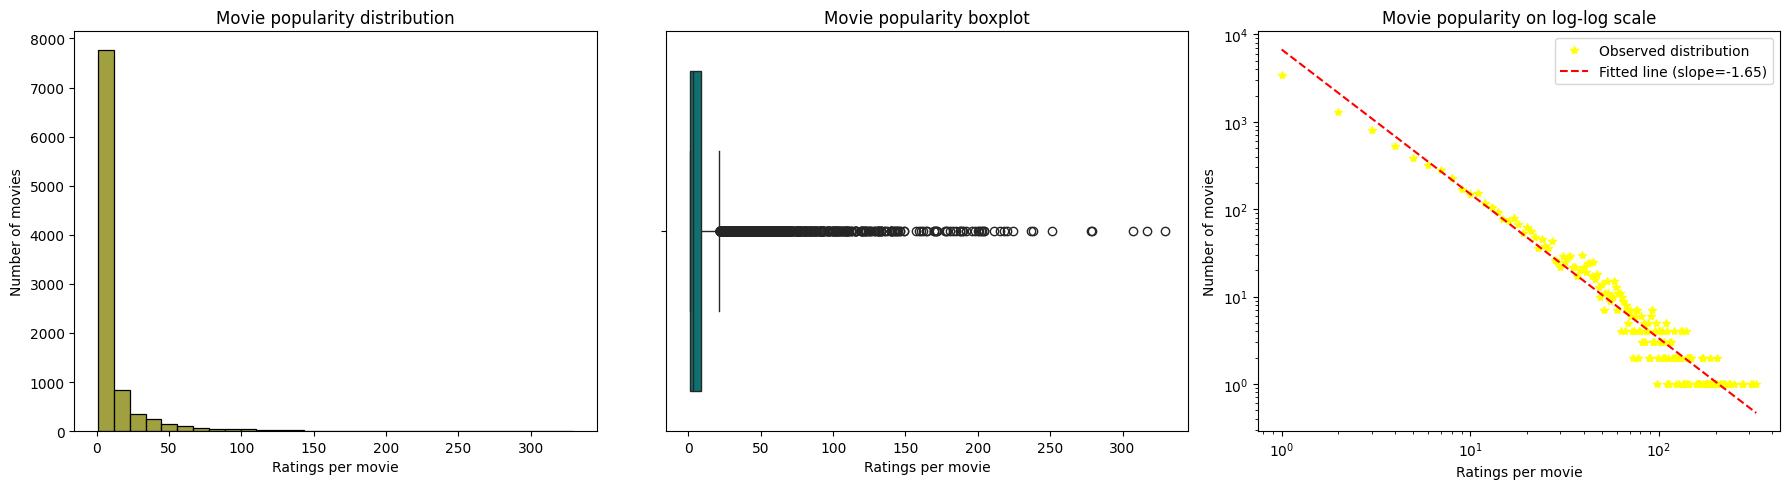

Estimated log-log slope (item popularity): -1.65


In [7]:
movie_popularity_counts = item_popularity.value_counts().sort_index()
mx = movie_popularity_counts.index.astype(float)
my = movie_popularity_counts.values.astype(float)
m_slope, m_intercept = np.polyfit(np.log10(mx), np.log10(my), 1)
m_fitted_y = 10 ** m_intercept * (mx ** m_slope)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(item_popularity, bins=30, ax=axes[0], color="olive")
axes[0].set_title("Movie popularity distribution")
axes[0].set_xlabel("Ratings per movie")
axes[0].set_ylabel("Number of movies")

sns.boxplot(x=item_popularity, ax=axes[1], color="teal")
axes[1].set_title("Movie popularity boxplot")
axes[1].set_xlabel("Ratings per movie")

axes[2].loglog(mx, my, marker="*", linestyle="none", color="yellow", label="Observed distribution")
axes[2].loglog(mx, m_fitted_y, linestyle="--", color="red", label=f"Fitted line (slope={m_slope:.2f})")
axes[2].set_title("Movie popularity on log-log scale")
axes[2].set_xlabel("Ratings per movie")
axes[2].set_ylabel("Number of movies")
axes[2].legend()

plt.tight_layout()
plt.show()
print("Estimated log-log slope (item popularity):", round(m_slope, 2))

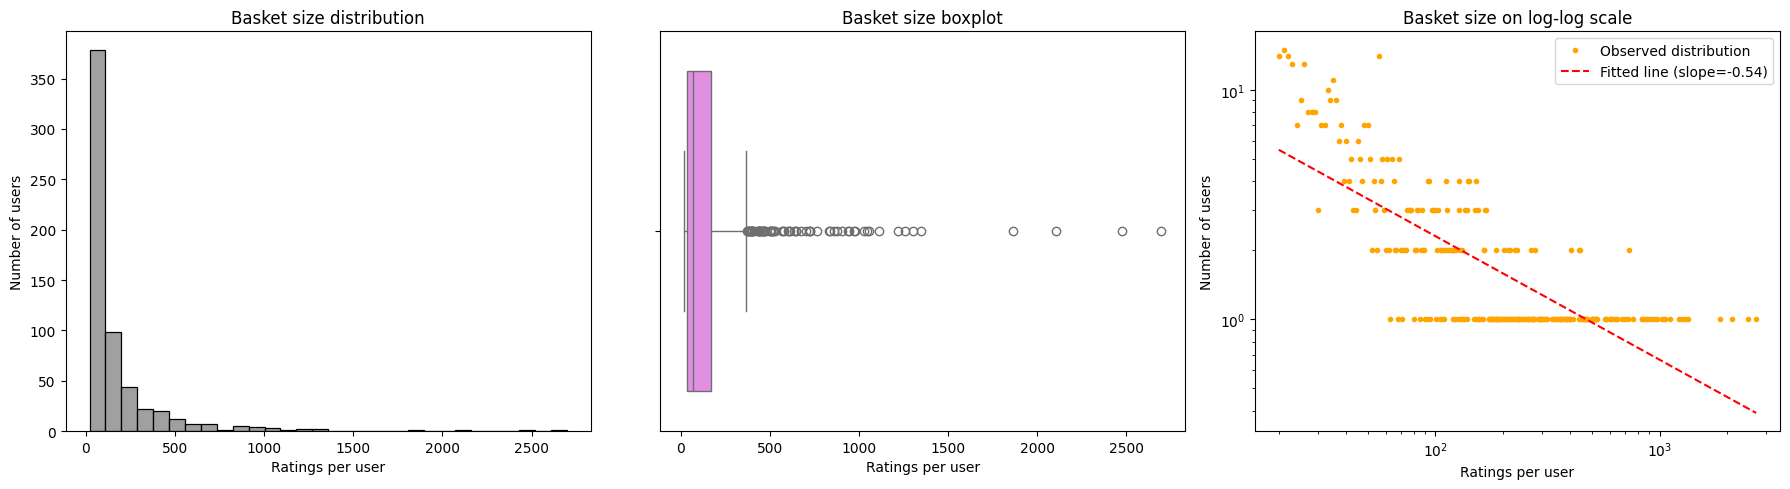

Estimated log-log slope (basket size): -0.54


In [8]:
basket_counts = user_activity.value_counts().sort_index()
x = basket_counts.index.astype(float)
y = basket_counts.values.astype(float)
slope, intercept = np.polyfit(np.log10(x), np.log10(y), 1)
fitted_y = 10 ** intercept * (x ** slope)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(user_activity, bins=30, ax=axes[0], color="grey")
axes[0].set_title("Basket size distribution")
axes[0].set_xlabel("Ratings per user")
axes[0].set_ylabel("Number of users")

sns.boxplot(x=user_activity, ax=axes[1], color="violet")
axes[1].set_title("Basket size boxplot")
axes[1].set_xlabel("Ratings per user")

axes[2].loglog(x, y, marker=".", linestyle="none", color="orange", label="Observed distribution")
axes[2].loglog(x, fitted_y, linestyle="--", color="red", label=f"Fitted line (slope={slope:.2f})")
axes[2].set_title("Basket size on log-log scale")
axes[2].set_xlabel("Ratings per user")
axes[2].set_ylabel("Number of users")
axes[2].legend()

plt.tight_layout()
plt.show()
print("Estimated log-log slope (basket size):", round(slope, 2))

In [9]:
import powerlaw

def fit_and_compare(values, label):
    fit = powerlaw.Fit(values, discrete=True, verbose=False)
    R, p = fit.distribution_compare('power_law', 'lognormal')
    print(f"[{label}] alpha = {fit.alpha:.2f}, xmin = {fit.xmin:.0f}")
    print(f"[{label}] R = {R:.2f}, p-value = {p:.3f}")
    print()

fit_and_compare(user_activity.values, "Basket size")
fit_and_compare(item_popularity.values, "Item popularity")

[Basket size] alpha = 2.07, xmin = 93
[Basket size] R = -10.10, p-value = 0.005

[Item popularity] alpha = 2.79, xmin = 39
[Item popularity] R = -15.45, p-value = 0.000



Basket size and item popularity both show right-skewed, heavy-tailed distributions. The formal comparison of a powerlaw and a lognormal fit gives a negative R and a small p-value for both (basket size: R = -10.10, p = 0.005; item popularity: R = -15.45, p = 0.000), meaning the lognormal distribution fits significantly better than a power law in both cases. The comparison uses a likelihood ratio test, where R is the log-likelihood ratio between the power law and lognormal fits — a negative R means the lognormal achieves a higher log-likelihood and therefore fits the data better than the power law. Therefore, neither distribution is well described by a strict power law, though both exhibit the kind of concentration typical of recommender system data — a small number of very active users and very popular items dominate the interactions. This is also visible in the log-log plots A true power law would appear as a straight line on a log-log plot. Both plots show curvature or scatter that deviates from the fitted line, which is consistent with lognormal being the better fit. 

In [10]:
import scipy.stats as stats

def fit_and_check_lognormal(values, label):
    fit = powerlaw.Fit(values, discrete=True, verbose=False)
    
    # Fit above xmin (via powerlaw package)
    tail_data = values[values >= fit.xmin]
    mu_tail = fit.lognormal.mu
    sigma_tail = fit.lognormal.sigma
    ks_tail, p_tail = stats.kstest(tail_data, 'lognorm', 
                                    args=(sigma_tail, 0, np.exp(mu_tail)))
    print(f"[{label}] xmin = {fit.xmin:.0f} "
          f"({len(tail_data)}/{len(values)} values above xmin)")
    print(f"[{label}] Lognormal TAIL (above xmin):  "
          f"mu={mu_tail:.2f}, sigma={sigma_tail:.2f}, "
          f"KS={ks_tail:.4f}, p={p_tail:.3f}")

    # Fit to full distribution (via scipy)
    shape, loc, scale = stats.lognorm.fit(values, floc=0)
    ks_full, p_full = stats.kstest(values, 'lognorm', args=(shape, loc, scale))
    mu_full = np.log(scale)
    sigma_full = shape
    print(f"[{label}] Lognormal FULL distribution: "
          f"mu={mu_full:.2f}, sigma={sigma_full:.2f}, "
          f"KS={ks_full:.4f}, p={p_full:.3f}")
    print()

fit_and_check_lognormal(user_activity.values, "Basket size")
fit_and_check_lognormal(item_popularity.values, "Item popularity")

[Basket size] xmin = 93 (263/610 values above xmin)
[Basket size] Lognormal TAIL (above xmin):  mu=4.27, sigma=1.29, KS=0.5804, p=0.000
[Basket size] Lognormal FULL distribution: mu=4.45, sigma=1.06, KS=0.0869, p=0.000

[Item popularity] xmin = 39 (668/9724 values above xmin)
[Item popularity] Lognormal TAIL (above xmin):  mu=3.06, sigma=0.92, KS=0.7428, p=0.000
[Item popularity] Lognormal FULL distribution: mu=1.28, sigma=1.31, KS=0.1902, p=0.000



We fit the lognormal distribution in two ways: once above a xmin that minimizes the Kolmogorov-Smirnov distance between the data and the fitted power law and once to the full distribution. The tail fit above xmin is motivated by the idea that power laws and related heavy-tailed distributions are typically only valid asymptotically, i.e. in the extreme upper tail, and forcing a fit on the full data would be distorted by the bulk of low-value observations that follow a different regime. The absolute goodness-of-fit results reveal that even the lognormal is not a satisfactory fit. For basket size, the lognormal fitted above xmin = 93 (covering 263 of 610 users) yields KS = 0.58, and fitted to the full distribution KS = 0.09, both with p = 0.000. For item popularity, the tail fit above xmin = 39 (covering only 668 of 9724 movies) yields KS = 0.74, and the full fit KS = 0.19, again with p = 0.000. The KS (Kolmogorov-Smirnov) statistic measures the maximum absolute difference between the empirical cumulative distribution of our data and the theoretical CDF of the fitted distribution — it ranges from 0 to 1, where 0 means a perfect fit. There is no universal cutoff, but values below ~0.05 are generally considered a good fit, values around 0.05–0.15 acceptable, and anything above that indicates meaningful deviation. The p-value here tests the null hypothesis that the data was drawn from the fitted distribution. Therefore, it is evident that neither of our distributions are well descirbed by a lognormal fit. The particularly poor tail fits suggest the lognormal struggles most with the extreme values, despite winning the relative comparison against the power law. The full-distribution fits are markedly better but still formally rejected. Therefore, both distributions are best described qualitatively as heavy-tailed rather than committed to any specific parametric family. 

In [11]:
unrated_movies = movies[~movies["movieId"].isin(ratings["movieId"])].shape[0]
genre_counts = movies["genres"].str.split("|").explode().value_counts().head(10)

print("Movies in catalog but never rated:", unrated_movies)
print("\nTop 10 genres in the movies table:")
print(genre_counts.to_string())

Movies in catalog but never rated: 18

Top 10 genres in the movies table:
genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779


The `movies` table adds useful context: the catalog is slightly larger than the rated subset, so a few movies have no ratings at all. The catalog is broad, with Drama and Comedy being the most common genres. Genre information is not used in the current collaborative filtering models, but could serve as content features in a later content-based extension.

### Main findings from data understanding
- The ratings matrix is very sparse.
- User activity is uneven with a small number of highly active users versus many rather inactive users.
- Movie popularity is also uneven and concentrated on a small number of films with a high number of ratings.
- Basket size and moviel popularity are heavy-tailed, but formal tests show they follow neither a lognormal distribution nor a power law.

## 3. Data Transformation

Before modelling, we need to prepare the data in a simpler format. The main steps are keeping the relevant columns, converting user and movie ids into numeric indices, creating an explicit version with ratings, creating a binary version for positive interactions, and splitting the data into train, validation and test sets.
We convert original user and movie ids into consecutive numeric indices to make it is easier to build user-item matrices for the recommendation models. The explicit version is needed for rating-prediction methods such as collaborative filtering or matrix-factorization approaches, while the implicit binary version is more appropriate for ranking methods, such as BPR or NCF. We define an implicit positive interaction as a rating of 4.0 or higher. Converting lower ratings (e.g., 1 or 2 stars) into positive implicit signals would incorrectly train the ranking models to recommend movies the user disliked.

In [12]:
ratings_model = ratings[["userId", "movieId", "rating", "timestamp", "timestamp_dt"]].copy()
user_ids = np.sort(ratings_model["userId"].unique())
movie_ids = np.sort(ratings_model["movieId"].unique())
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}
ratings_model["user_idx"] = ratings_model["userId"].map(user_to_idx)
ratings_model["movie_idx"] = ratings_model["movieId"].map(movie_to_idx)
print(ratings_model.head(10))

IMPLICIT_THRESHOLD = 4.0
# Create the base implicit dataset (Positive interactions only)
implicit_feedback = ratings_model.assign( interaction=(ratings_model["rating"] >= IMPLICIT_THRESHOLD).astype(np.int8))
implicit_feedback = implicit_feedback[implicit_feedback["interaction"] == 1].copy()

   userId  movieId  rating  timestamp        timestamp_dt  user_idx  movie_idx
0       1        1     4.0  964982703 2000-07-30 18:45:03         0          0
1       1        3     4.0  964981247 2000-07-30 18:20:47         0          2
2       1        6     4.0  964982224 2000-07-30 18:37:04         0          5
3       1       47     5.0  964983815 2000-07-30 19:03:35         0         43
4       1       50     5.0  964982931 2000-07-30 18:48:51         0         46
5       1       70     3.0  964982400 2000-07-30 18:40:00         0         62
6       1      101     5.0  964980868 2000-07-30 18:14:28         0         89
7       1      110     4.0  964982176 2000-07-30 18:36:16         0         97
8       1      151     5.0  964984041 2000-07-30 19:07:21         0        124
9       1      157     5.0  964984100 2000-07-30 19:08:20         0        130


To ensure our models have enough signal to learn and to allow for proper chronological data splitting, we exclude users with fewer than 5 positive interactions.

In [13]:
MIN_INTERACTIONS = 5
eligible_users = implicit_feedback.groupby("userId").size().loc[lambda s: s >= MIN_INTERACTIONS].index

implicit_filtered = implicit_feedback[implicit_feedback["userId"].isin(eligible_users)].copy()
explicit_filtered = ratings_model[ratings_model["userId"].isin(eligible_users)].copy()

print("Users before filtering:", ratings_model["userId"].nunique())
print("Users after filtering:", explicit_filtered["userId"].nunique())

Users before filtering: 610
Users after filtering: 603


In [14]:
RANDOM_STATE = 42
unique_eligible_users = implicit_filtered["userId"].unique()
sampled_users, _ = train_test_split(unique_eligible_users, train_size=0.2, random_state=RANDOM_STATE)

probe_implicit = implicit_filtered[implicit_filtered["userId"].isin(sampled_users)].copy()
probe_explicit = explicit_filtered[explicit_filtered["userId"].isin(sampled_users)].copy()

Eligible users basket size summary:
count     603.000000
mean      166.943615
std       270.609648
min        20.000000
25%        36.000000
50%        73.000000
75%       170.500000
max      2698.000000
dtype: float64

Probe sample basket size summary:
count     120.000000
mean      155.275000
std       202.012603
min        20.000000
25%        32.750000
50%        64.500000
75%       192.250000
max      1346.000000
dtype: float64


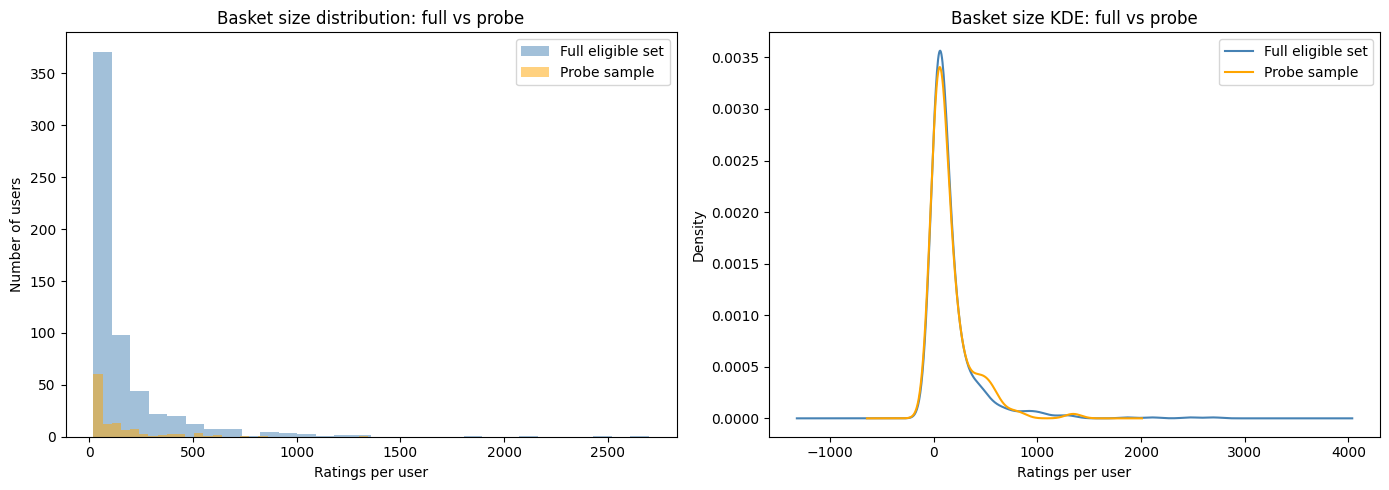

In [15]:
print("Eligible users basket size summary:")
print(explicit_filtered.groupby("userId").size().describe())
print("\nProbe sample basket size summary:")
print(probe_explicit.groupby("userId").size().describe())
full_basket = explicit_filtered.groupby("userId").size().rename("basket_size")
probe_basket = probe_explicit.groupby("userId").size().rename("basket_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histogram
axes[0].hist(full_basket, bins=30, alpha=0.5, color="steelblue", label="Full eligible set")
axes[0].hist(probe_basket, bins=30, alpha=0.5, color="orange", label="Probe sample")
axes[0].set_title("Basket size distribution: full vs probe")
axes[0].set_xlabel("Ratings per user")
axes[0].set_ylabel("Number of users")
axes[0].legend()

# Overlaid KDE
full_basket.plot.kde(ax=axes[1], color="steelblue", label="Full eligible set")
probe_basket.plot.kde(ax=axes[1], color="orange", label="Probe sample")
axes[1].set_title("Basket size KDE: full vs probe")
axes[1].set_xlabel("Ratings per user")
axes[1].legend()

plt.tight_layout()
plt.show()

The basket size distribution of the probe sample closely follows the shape of the full eligible set in both the histogram and the KDE. The overall spread and skew are preserved, which suggests the 20% random sample is representative and that results obtained on the probe can be expected to generalise to the full data. The probe sample also has its own train, validation and test split, so the same pipeline can be tested on a smaller dataset before moving to the full data.

In [16]:
from scipy.stats import ks_2samp

ks_stat, p_val = ks_2samp(full_basket.values, probe_basket.values)
print(f"Two-sample KS test: KS={ks_stat:.4f}, p={p_val:.3f}")

Two-sample KS test: KS=0.0529, p=0.925


The two-sample KS test confirms that the probe sample and the full eligible set follow virtually identical basket size distributions (KS = 0.05, p = 0.925), meaning the null hypothesis of equal distributions cannot be rejected. The probe sample is therefore representative of the full eligible user population in terms of rating activity.

A chronological split is applied to preserve temporal integrity, ensuring that no future interactions leak into the training set. The split is 70% train, 15% validation and 15% test, which gives enough data for training while still leaving separate data for tuning and evaluation.

In [17]:
def chronological_user_split(df, user_col="userId", time_col="timestamp", train_size=0.7, val_size=0.15):
    train_parts, val_parts, test_parts = [], [], []

    for _, user_df in df.sort_values([user_col, time_col]).groupby(user_col):
        n = len(user_df)
        train_end = max(1, int(np.floor(n * train_size)))
        val_end = max(train_end + 1, int(np.floor(n * (train_size + val_size)))) if n >= 3 else train_end

        if n == 1:
            train_parts.append(user_df)
            continue
        if n == 2:
            train_parts.append(user_df.iloc[:1])
            test_parts.append(user_df.iloc[1:])
            continue
        if n == 3:
            train_parts.append(user_df.iloc[:1])
            val_parts.append(user_df.iloc[1:2])
            test_parts.append(user_df.iloc[2:])
            continue

        train_parts.append(user_df.iloc[:train_end])
        val_parts.append(user_df.iloc[train_end:val_end])
        test_parts.append(user_df.iloc[val_end:])

    train_df = pd.concat(train_parts).reset_index(drop=True) if train_parts else pd.DataFrame(columns=df.columns)
    val_df = pd.concat(val_parts).reset_index(drop=True) if val_parts else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_parts).reset_index(drop=True) if test_parts else pd.DataFrame(columns=df.columns)
    return train_df, val_df, test_df
# Split the FULL datasets
explicit_train, explicit_val, explicit_test = chronological_user_split(explicit_filtered)
implicit_train, implicit_val, implicit_test = chronological_user_split(implicit_filtered)

# Split the PROBE datasets
probe_explicit_train, probe_explicit_val, probe_explicit_test = chronological_user_split(probe_explicit)
probe_implicit_train, probe_implicit_val, probe_implicit_test = chronological_user_split(probe_implicit)

print(f"Full  — explicit train: {len(explicit_train)}, val: {len(explicit_val)}, test: {len(explicit_test)}")
print(f"Full  — implicit train: {len(implicit_train)}, val: {len(implicit_val)}, test: {len(implicit_test)}")
print(f"Probe — explicit train: {len(probe_explicit_train)}, val: {len(probe_explicit_val)}, test: {len(probe_explicit_test)}")
print(f"Probe — implicit train: {len(probe_implicit_train)}, val: {len(probe_implicit_val)}, test: {len(probe_implicit_test)}")

Full  — explicit train: 70197, val: 15077, test: 15393
Full  — implicit train: 33719, val: 7260, test: 7583
Probe — explicit train: 12992, val: 2787, test: 2854
Probe — implicit train: 6032, val: 1300, test: 1369


### Transformation conclusions
- We prepared a simpler table for modelling.
- We created explicit and implicit versions of the data for different recommendation settings.
- We split the data into train, validation and test parts.
- We created a probe sample that is representative of the full sample.

## 4. Modeling (Probe Sample)

### Formatting Dataframes

Before training our baseline models, we must convert our training dataframes into the specific mathematical structures required by the algorithms:
1. **Association Rules (AR):** Requires a transactional "list of lists" format.
2. **Collaborative Filtering (CF) & Matrix Factorization (MFPQ):** Require Sparse Matrices.

Association Rules Baskets

In [18]:
ar_baskets_train = implicit_train.groupby('user_idx')['movie_idx'].apply(list).tolist()
ar_baskets_probe_train = probe_implicit_train.groupby('user_idx')['movie_idx'].apply(list).tolist()

if len(ar_baskets_probe_train) > 0:
    print(f"Sample AR basket (first user's items): {ar_baskets_probe_train[0][:10]}")

Sample AR basket (first user's items): [7355, 8810, 8448, 2670, 7241, 4607, 8287, 6784, 6236, 291]


Sparse matrices for Matrix Factorization and Collaborative Filtering

In [19]:
matrix_shape = (len(user_ids), len(movie_ids))

# PROBE MATRICES
# Explicit
probe_explicit_train_matrix = sparse.csr_matrix((probe_explicit_train["rating"].astype(np.float32), (probe_explicit_train["user_idx"], probe_explicit_train["movie_idx"])), shape=matrix_shape)
probe_explicit_val_matrix = sparse.csr_matrix((probe_explicit_val["rating"].astype(np.float32), (probe_explicit_val["user_idx"], probe_explicit_val["movie_idx"])), shape=matrix_shape)
probe_explicit_test_matrix = sparse.csr_matrix((probe_explicit_test["rating"].astype(np.float32), (probe_explicit_test["user_idx"], probe_explicit_test["movie_idx"])), shape=matrix_shape)

# Implicit
probe_implicit_train_matrix = sparse.csr_matrix((probe_implicit_train["interaction"].astype(np.float32), (probe_implicit_train["user_idx"], probe_implicit_train["movie_idx"])), shape=matrix_shape)
probe_implicit_val_matrix = sparse.csr_matrix((probe_implicit_val["interaction"].astype(np.float32), (probe_implicit_val["user_idx"], probe_implicit_val["movie_idx"])), shape=matrix_shape)
probe_implicit_test_matrix = sparse.csr_matrix((probe_implicit_test["interaction"].astype(np.float32), (probe_implicit_test["user_idx"], probe_implicit_test["movie_idx"])), shape=matrix_shape)


#FULL MATRICES
# Explicit
explicit_train_matrix = sparse.csr_matrix((explicit_train["rating"].astype(np.float32), (explicit_train["user_idx"], explicit_train["movie_idx"])), shape=matrix_shape)
explicit_val_matrix = sparse.csr_matrix((explicit_val["rating"].astype(np.float32), (explicit_val["user_idx"], explicit_val["movie_idx"])), shape=matrix_shape)
explicit_test_matrix = sparse.csr_matrix((explicit_test["rating"].astype(np.float32), (explicit_test["user_idx"], explicit_test["movie_idx"])), shape=matrix_shape)

# Implicit
implicit_train_matrix = sparse.csr_matrix((implicit_train["interaction"].astype(np.float32), (implicit_train["user_idx"], implicit_train["movie_idx"])), shape=matrix_shape)
implicit_val_matrix = sparse.csr_matrix((implicit_val["interaction"].astype(np.float32), (implicit_val["user_idx"], implicit_val["movie_idx"])), shape=matrix_shape)
implicit_test_matrix = sparse.csr_matrix((implicit_test["interaction"].astype(np.float32), (implicit_test["user_idx"], implicit_test["movie_idx"])), shape=matrix_shape)

print(f"Probe Implicit Train Matrix nnz: {probe_implicit_train_matrix.nnz}")
print(f"Probe Implicit Val Matrix nnz: {probe_implicit_val_matrix.nnz}")
print(f"Probe Implicit Test Matrix nnz: {probe_implicit_test_matrix.nnz}")

Probe Implicit Train Matrix nnz: 6032
Probe Implicit Val Matrix nnz: 1300
Probe Implicit Test Matrix nnz: 1369


### Evaluation Helper Functions and Baseline

In [20]:
# Prepare matrices
train_item_user = probe_implicit_train_matrix.T.tocsr()     # (9724, 610)
train_user_item = probe_implicit_train_matrix.tocsr()   # (610, 9724)
val_user_item   = probe_implicit_val_matrix.tocsr()     # (610, 9724)

In [21]:
import numpy as np
import random
from scipy import sparse
import matplotlib.pyplot as plt
import itertools

def get_top_k_recommendations(model, train_user_item, user_ids, K=3):
    recommendations = {}
    for u in user_ids:
        user_row = train_user_item[u]
        if user_row.nnz == 0:          # skip users with no training interactions
            continue
        ids, _ = model.recommend(u, user_row, N=K, filter_already_liked_items=True)
        recommendations[u] = list(ids)
    return recommendations


def precision_recall_at_k(recommendations, val_matrix_ui, K=3):
    """
    Computes mean Precision@K and Recall@K across all users
    who have at least one positive in the val set.
    """
    precisions, recalls = [], []

    for u, rec_items in recommendations.items():
        # ground truth positives for this user in val
        val_items = set(val_matrix_ui[u].indices)
        if len(val_items) == 0:
            continue

        hits = len(set(rec_items) & val_items)
        precisions.append(hits / K)
        recalls.append(hits / len(val_items))

    return np.mean(precisions), np.mean(recalls)


def f1_at_k(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def evaluate(model, train_user_item, val_user_item, K=3):
    n_users = val_user_item.shape[0]
    user_ids = range(n_users)
    recs = get_top_k_recommendations(model, train_user_item, user_ids, K)
    p, r = precision_recall_at_k(recs, val_user_item, K)
    f1 = f1_at_k(p, r)
    return p, r, f1

In [22]:
# baseline for binary data
def popularity_baseline(train_user_item, val_user_item, K=3):
    # Count interactions per item across all users
    item_popularity = np.array(train_user_item.sum(axis=0)).flatten()  # (n_items,)
    top_k_items = np.argsort(item_popularity)[::-1][:K]                # K most popular items

    precisions, recalls = [], []
    n_users = val_user_item.shape[0]

    for u in range(n_users):
        val_items = set(val_user_item[u].indices)
        if len(val_items) == 0:
            continue

        # Filter out items the user already interacted with in training
        train_items = set(train_user_item[u].indices)
        recs = [i for i in top_k_items if i not in train_items][:K]

        hits = len(set(recs) & val_items)
        precisions.append(hits / K)
        recalls.append(hits / len(val_items))

    p, r = np.mean(precisions), np.mean(recalls)
    f1 = f1_at_k(p, r)
    print(f"Popularity Baseline → P@{K}={p:.4f}  R@{K}={r:.4f}  F1@{K}={f1:.4f}")
    return p, r, f1

popularity_baseline(train_user_item, val_user_item, K=3)

Popularity Baseline → P@3=0.0222  R@3=0.0108  F1@3=0.0146


(np.float64(0.02222222222222222),
 np.float64(0.01084030459030459),
 np.float64(0.014572126258120904))

The baseline computed based on recommending the most popular movies to every user. As usual for recommender systems, Precision, Recall, as well as F1 are very low. This is expected due to the complex nature of the problem to recommend 3 out of 10,000 items.

### Bayesian Preference Ranking (BPR)

factors=  5  lr=0.0010  iter= 10  reg=0.0001  →  P@3=0.0222  R@3=0.0057  F1@3=0.0090
factors=  5  lr=0.0010  iter= 10  reg=0.0010  →  P@3=0.0222  R@3=0.0057  F1@3=0.0090
factors=  5  lr=0.0010  iter= 10  reg=0.0100  →  P@3=0.0222  R@3=0.0057  F1@3=0.0090


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


factors=  5  lr=0.0010  iter= 10  reg=0.1000  →  P@3=0.0167  R@3=0.0052  F1@3=0.0080
factors=  5  lr=0.0010  iter= 50  reg=0.0001  →  P@3=0.0500  R@3=0.0223  F1@3=0.0308
factors=  5  lr=0.0010  iter= 50  reg=0.0010  →  P@3=0.0500  R@3=0.0223  F1@3=0.0308
factors=  5  lr=0.0010  iter= 50  reg=0.0100  →  P@3=0.0500  R@3=0.0223  F1@3=0.0308
factors=  5  lr=0.0010  iter= 50  reg=0.1000  →  P@3=0.0500  R@3=0.0223  F1@3=0.0308
factors=  5  lr=0.0010  iter=100  reg=0.0001  →  P@3=0.0500  R@3=0.0209  F1@3=0.0295
factors=  5  lr=0.0010  iter=100  reg=0.0010  →  P@3=0.0500  R@3=0.0209  F1@3=0.0295
factors=  5  lr=0.0010  iter=100  reg=0.0100  →  P@3=0.0500  R@3=0.0209  F1@3=0.0295
factors=  5  lr=0.0010  iter=100  reg=0.1000  →  P@3=0.0472  R@3=0.0195  F1@3=0.0276
factors=  5  lr=0.0010  iter=200  reg=0.0001  →  P@3=0.0472  R@3=0.0209  F1@3=0.0289
factors=  5  lr=0.0010  iter=200  reg=0.0010  →  P@3=0.0500  R@3=0.0210  F1@3=0.0296
factors=  5  lr=0.0010  iter=200  reg=0.0100  →  P@3=0.0500  R@3=

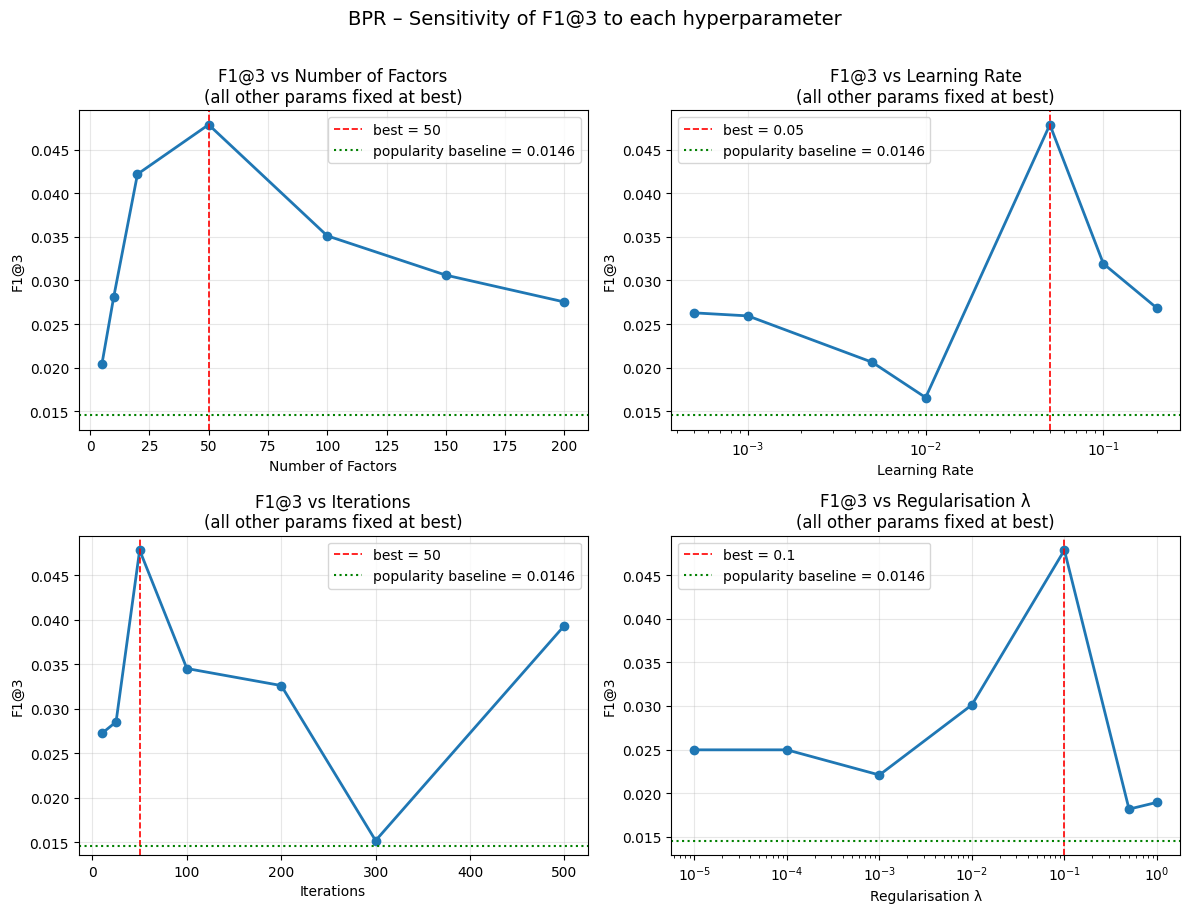

In [23]:
from implicit.bpr import BayesianPersonalizedRanking

def fit_and_evaluate(factors, lr, iterations, reg,
                     train_user_item, val_user_item, K=3):
    model = BayesianPersonalizedRanking(
        factors=factors,
        learning_rate=lr,
        iterations=iterations,
        regularization=reg,
        random_state=42,
        verify_negative_samples=True,
    )
    model.fit(train_user_item, show_progress=False)
    p, r, f1 = evaluate(model, train_user_item, val_user_item, K)
    return p, r, f1

# Step 2 – Grid search
param_grid = {
    "factors":    [5, 10, 20, 50],
    "lr":         [0.001, 0.01, 0.05, 0.1],
    "iterations": [10, 50, 100, 200],
    "reg":        [0.0001, 0.001, 0.01, 0.1],
}

best_f1    = -1
best_params = {}
grid_results = []

for factors, lr, iterations, reg in itertools.product(
        param_grid["factors"], param_grid["lr"],
        param_grid["iterations"], param_grid["reg"]):

    p, r, f1 = fit_and_evaluate(
        factors, lr, iterations, reg,
        train_user_item, val_user_item
    )
    grid_results.append(dict(factors=factors, lr=lr,
                             iterations=iterations, reg=reg,
                             precision=p, recall=r, f1=f1))
    print(f"factors={factors:3d}  lr={lr:.4f}  iter={iterations:3d}  "
          f"reg={reg:.4f}  →  P@3={p:.4f}  R@3={r:.4f}  F1@3={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_params = dict(factors=factors, lr=lr,
                           iterations=iterations, reg=reg)

print("\nBest params:", best_params)
print(f"Best F1@3:  {best_f1:.4f}")


# Step 3 – Sensitivity line plots
# Fix all params at best values, vary one at a time
sweep = {
    "factors":    [5, 10, 20, 50, 100, 150, 200],
    "lr":         [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "iterations": [10, 25, 50, 100, 200, 300, 500],
    "reg":        [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0],
}

labels = {
    "factors":    "Number of Factors",
    "lr":         "Learning Rate",
    "iterations": "Iterations",
    "reg":        "Regularisation λ",
}

# Compute once before the plot
_, _, pop_f1 = popularity_baseline(train_user_item, val_user_item, K=3)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (param, values) in zip(axes, sweep.items()):
    f1_scores = []
    for v in values:
        kwargs = {**best_params, param: v}
        _, _, f1 = fit_and_evaluate(
            kwargs["factors"], kwargs["lr"],
            kwargs["iterations"], kwargs["reg"],
            train_user_item, val_user_item
        )
        f1_scores.append(f1)

    ax.plot(values, f1_scores, marker="o", linewidth=2)
    ax.axvline(best_params[param], color="red", linestyle="--",
               linewidth=1.2, label=f"best = {best_params[param]}")
    ax.axhline(pop_f1, color="green", linestyle=":", linewidth=1.5,   # <-- added
               label=f"popularity baseline = {pop_f1:.4f}")           # <-- added
    ax.set_xlabel(labels[param])
    ax.set_ylabel("F1@3")
    ax.set_title(f"F1@3 vs {labels[param]}\n(all other params fixed at best)")
    if param in ("lr", "reg"):
        ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("BPR – Sensitivity of F1@3 to each hyperparameter", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("bpr_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

A grid search was conducted over four hyperparameters — number of latent factors {5, 10, 20, 50}, learning rate {0.001, 0.01, 0.05, 0.1}, number of iterations {10, 50, 100, 200}, and regularisation λ {0.0001, 0.001, 0.01, 0.1} — yielding 256 combinations evaluated at K=3. The best configuration was factors=50, lr=0.05, iterations=50, and λ=0.1, achieving P@3=0.0694, R@3=0.0341, and F1@3=0.0457.
This represents a threefold improvement over the popularity baseline (F1@3=0.0146), demonstrating that BPR learns meaningful personalised structure beyond simple item popularity.

The sensitivity plots reveal several insights. For the number of factors, performance peaks at 50 and degrades beyond that, suggesting that higher-dimensional embeddings overfit given the limited dataset size (610 users). The learning rate shows a clear optimum at 0.05, with both lower and higher values reducing performance. Lower rates likely underfit within the fixed iteration budget, while higher rates overshoot. Training beyond 50 iterations appears counterproductive, with performance degrading sharply before recovering at 500 iterations — possibly indicating that the model briefly overshoots an optimum before converging again. For regularisation, the narrow peak at λ=0.1 suggests the model requires a careful balance between underfitting (too little regularisation) and over-penalising the latent factors (too much).
Overall, BPR performs well above the baseline but the sensitivity plots highlight that the optimum is relatively sharp — small deviations from the best parameters lead to noticeable drops in F1@3, suggesting the model requires careful tuning on this dataset. Regardless of parameter tuning, we can see in the sensitivity plots that the F1@3 is higher than the baseline, even for suboptimal parameter values.

### Neural Collaborative Filtering (NCF)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import json
import itertools

# Datasets

class ImplicitDataset(Dataset):
    def __init__(self, user_item_csr, num_neg=3): #  for every movie a user watched, randomly sample num_neg movies they didn't watch and label 0
        self.num_neg = num_neg
        n_users, n_items = user_item_csr.shape
        users, items, labels = [], [], []
        for u in range(n_users):
            pos_items = user_item_csr[u].indices
            if len(pos_items) == 0:
                continue
            for i in pos_items:
                users.append(u); items.append(i); labels.append(1.0)
            pos_set = set(pos_items)
            neg_sampled = 0
            while neg_sampled < num_neg * len(pos_items):
                j = random.randint(0, n_items - 1)
                if j not in pos_set:
                    users.append(u); items.append(j); labels.append(0.0)
                    neg_sampled += 1
        self.users  = torch.tensor(users,  dtype=torch.long)
        self.items  = torch.tensor(items,  dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


class ExplicitDataset(Dataset):
    def __init__(self, user_item_csr):
        coo = user_item_csr.tocoo()
        self.users  = torch.tensor(coo.row,  dtype=torch.long)
        self.items  = torch.tensor(coo.col,  dtype=torch.long)
        self.labels = torch.tensor(coo.data, dtype=torch.float)  # actual ratings

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


# Model

ACT_FNS = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid, "tanh": nn.Tanh, "leaky_relu": nn.LeakyReLU}

class NeuralCF(nn.Module):
    def __init__(self, n_users, n_items, factors=8, layers=[64, 32, 16],
                 act_fn="relu", mode="implicit"):
        super().__init__()
        self.mode = mode
        self.P = nn.Embedding(n_users, factors)
        self.Q = nn.Embedding(n_items, factors)

        act = ACT_FNS[act_fn]
        mlp_layers = []
        in_dim = 2 * factors
        for out_dim in layers:
            mlp_layers += [nn.Linear(in_dim, out_dim), act()]
            in_dim = out_dim
        mlp_layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*mlp_layers)

        nn.init.normal_(self.P.weight, std=0.01)
        nn.init.normal_(self.Q.weight, std=0.01)

    def forward(self, u, i):
        x = torch.cat([self.P(u), self.Q(i)], dim=1)
        out = self.mlp(x).squeeze()
        if self.mode == "explicit":
            out = 1 + 4 * torch.sigmoid(out)   # scale to [1, 5]
        return out


# Training

def train_ncf(model, loader, num_epochs=50, lr=0.001, weight_decay=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # using ADAM as ADAM is more sophisticated than SGD
    criterion = nn.BCEWithLogitsLoss() if model.mode == "implicit" else nn.MSELoss()
    device    = next(model.parameters()).device

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for u, i, y in loader:
            u, i, y = u.to(device), i.to(device), y.to(device)
            pred = model(u, i)
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

# Recommender wrapper 

class NCFRecommender:
    def __init__(self, model, n_items, device):
        self.model        = model
        self.n_items      = n_items
        self.device       = device
        self._item_tensor = torch.arange(n_items, device=device)

    def recommend(self, userid, user_items_row, N=3, filter_already_liked_items=True):
        self.model.eval()
        with torch.no_grad():
            u      = torch.tensor([userid] * self.n_items, device=self.device)
            scores = self.model(u, self._item_tensor).cpu().numpy()
        if filter_already_liked_items:
            scores[user_items_row.indices] = -np.inf
        top_ids = np.argsort(scores)[::-1][:N]
        return top_ids, scores[top_ids]


# fit_and_evaluate

def fit_and_evaluate_ncf(factors, layers, act_fn, num_epochs, batch_size, lr, weight_decay,
                         train_user_item, val_user_item, mode="implicit", num_neg=3, K=3):
    n_users, n_items = train_user_item.shape
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = (ImplicitDataset(train_user_item, num_neg=num_neg)
               if mode == "implicit"
               else ExplicitDataset(train_user_item))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = NeuralCF(n_users, n_items, factors=factors, layers=layers,
                     act_fn=act_fn, mode=mode).to(device)
    train_ncf(model, loader, num_epochs=num_epochs, lr=lr, weight_decay=weight_decay)

    recommender = NCFRecommender(model, n_items, device)
    p, r, f1    = evaluate(recommender, train_user_item, val_user_item, K)
    return p, r, f1


# Random search

N_TRIALS = 500 

param_grid_ncf = {
    "factors":      [5, 10, 20, 50],
    "layers":       [[64, 32, 16], [128, 64, 32], [32, 32, 32, 16, 16], [128, 128]],
    "act_fn":       ["relu", "sigmoid"],
    "num_epochs":   [10, 50, 100, 200],
    "batch_size":   [256, 512],
    "lr":           [0.001, 0.01, 0.05, 0.1],
    "weight_decay": [0.0001, 0.001, 0.01, 0.1],
}

def sample_params():
    return {
        "factors":      random.choice(param_grid_ncf["factors"]),
        "layers":       random.choice(param_grid_ncf["layers"]),
        "act_fn":       random.choice(param_grid_ncf["act_fn"]),
        "num_epochs":   random.choice(param_grid_ncf["num_epochs"]),
        "batch_size":   random.choice(param_grid_ncf["batch_size"]),
        "lr":           random.choice(param_grid_ncf["lr"]),
        "weight_decay": random.choice(param_grid_ncf["weight_decay"]),
    }

try:
    with open("ncf_results.json", "r") as f:
        ncf_results = json.load(f)
    print(f"Resuming from {len(ncf_results)} existing results")
except FileNotFoundError:
    ncf_results = []
    print("Starting fresh") 

random.seed(42)
for MODE in ["implicit", "explicit"]:
    if MODE == "implicit":
        train_mat = probe_implicit_train_matrix   # (610, 9724) binary
        val_mat   = probe_implicit_val_matrix
    else:
        train_mat = probe_explicit_train_matrix   # (610, 9724) ratings 1-5
        val_mat   = probe_explicit_val_matrix

    print(f"\n{'='*60}")
    print(f"  NCF Random Search — mode = {MODE.upper()}")
    print(f"{'='*60}")

    best_f1, best_params = -1, {}

    counter = 0

    for trial in range(N_TRIALS):
        params = sample_params()
        factors, layers, act_fn = params["factors"], params["layers"], params["act_fn"]
        num_epochs, batch_size  = params["num_epochs"], params["batch_size"]
        lr, wd                  = params["lr"], params["weight_decay"]
        
        # skip if already computed
        already_done = any(
            r["factors"] == factors and
            r["layers"]  == str(layers) and
            r["act_fn"]  == act_fn and
            r["num_epochs"]   == num_epochs and
            r["batch_size"]   == batch_size and
            r["lr"]           == lr and
            r["weight_decay"] == wd and
            r["mode"]         == MODE
            for r in ncf_results
        )
        if already_done:
            counter += 1
            if counter % 100 == 0:
                print(f"[{counter}/{N_TRIALS}] skipping already computed...")
            continue

        p, r, f1 = fit_and_evaluate_ncf(
            factors, layers, act_fn, num_epochs, batch_size, lr, wd,
            train_mat, val_mat, mode=MODE
        )
        counter += 1
        ncf_results.append(dict(
            factors=factors, layers=str(layers), act_fn=act_fn,   # str(layers) makes it hashable
            num_epochs=num_epochs, batch_size=batch_size,
            lr=lr, weight_decay=wd,
            precision=p, recall=r, f1=f1,
            mode=MODE
        ))

        with open("ncf_results.json", "w") as f:
            json.dump(ncf_results, f)
        
        if counter % 10 == 0:
            print(f"[{counter}/{N_TRIALS}] last F1@3={f1:.4f}  ")

for MODE in ["implicit", "explicit"]:
    df = pd.DataFrame(ncf_results)
    df_mode = df[df["mode"] == MODE]
    
    if len(df_mode) == 0:
        print(f"No results yet for {MODE}")
        continue

    best_row = df_mode.loc[df_mode["f1"].idxmax()]
    print(f"\nBest NCF [{MODE}] params: {best_row.to_dict()}")
    print(f"Best NCF [{MODE}] P@3:    {best_row['precision']:.4f}")
    print(f"Best NCF [{MODE}] R@3:    {best_row['recall']:.4f}")
    print(f"Best NCF [{MODE}] F1@3:   {best_row['f1']:.4f}")

Resuming from 751 existing results

  NCF Random Search — mode = IMPLICIT
[20/500] last F1@3=0.0064  
[40/500] last F1@3=0.0008  
[50/500] last F1@3=0.0064  
[60/500] last F1@3=0.0064  
[70/500] last F1@3=0.0064  
[90/500] last F1@3=0.0064  


In [ ]:
import pandas as pd

df = pd.DataFrame(ncf_results)
df_mode = df[df["mode"] == MODE]   # filter by implicit or explicit

sweep_ncf = {
    "factors":      [5, 10, 20, 50],
    "layers":       [[64, 32, 16], [128, 64, 32], [32, 32, 32, 16, 16], [128, 128]],
    "num_epochs":   [10, 50, 100, 200],
    "lr":           [0.001, 0.01, 0.05, 0.1],
    "weight_decay": [0.0001, 0.001, 0.01, 0.1]
}

labels_ncf = {
    "factors":      "Number of Factors",
    "layers": "Number of Layers",
    "lr":           "Learning Rate",
    "num_epochs":   "Epochs",
    "weight_decay": "Weight Decay λ",
}

for MODE in ["implicit", "explicit"]:
    df_mode = df[df["mode"] == MODE]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()

    for ax, (param, values) in zip(axes, sweep_ncf.items()):
        # for each value of this param, take the best f1 across all other param combinations
        f1_scores = []
        for v in values:
            subset = df_mode[df_mode[param] == v]
            if len(subset) == 0:
                f1_scores.append(np.nan)
            else:
                f1_scores.append(subset["f1"].max())   # best f1 for this param value

        ax.plot(values, f1_scores, marker="o", linewidth=2)
        ax.axvline(best_params[param], color="red", linestyle="--",
                   linewidth=1.2, label=f"best = {best_params[param]}")
        ax.axhline(pop_f1, color="green", linestyle=":", linewidth=1.5,
                   label=f"popularity baseline = {pop_f1:.4f}")
        ax.set_xlabel(labels_ncf[param])
        ax.set_ylabel("F1@3")
        ax.set_title(f"F1@3 vs {labels_ncf[param]}\n(all other params fixed at best)")
        if param in ("lr", "weight_decay"):
            ax.set_xscale("log")
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"NCF [{MODE}] – Sensitivity of F1@3 to each hyperparameter",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"ncf_sensitivity_{MODE}.png", dpi=150, bbox_inches="tight")
    plt.show()